In [209]:
library(tidyverse)
library(dplyr)
library(cowplot)
library(ggplot2)
library(BSDA)

# Load files ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [210]:
# Read file
fp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/saliva/tp1_nulliparous/2025-12-09_no_min_abundance_fp_tp1_nulliparous_saliva.csv", header = TRUE)
sp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/saliva/tp1_nulliparous/2025-12-09_no_min_abundance_sp_tp1_nulliparous_saliva.csv", header = TRUE)
combined_fp_sp <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/saliva/tp1_nulliparous/2025-12-09_no_min_abundance_combined_nulliparous_fp_sp_tp1_saliva.csv", header = TRUE)

In [211]:
combined_fp_sp$Group

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "Second pregnancy" "Second pregnancy" "Second pregnancy"
[13] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[17] "Second pregnancy" "Second pregnancy"

In [212]:
head(fp_tp1)
dim(fp_tp1)

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<chr>,<int>,<chr>,<lgl>,<lgl>,<int>,<chr>
1,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,2,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
2,S50f102c,NA,0,0,0,2018-08-05,P50f102c,0,32,3,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
3,S735d77f,NA,0,0,0,2018-08-24,P735d77f,0,25,2,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
4,S9026714,NA,0,0,2,2019-01-02,P7ece52e,0,25,2,⋯,NA,NA,NA,NA,41,Induction,NA,NA,0,First pregnancy
5,Se5be4e8,NA,0,0,0,2018-07-03,Pbbb08bd,0,33,3,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,First pregnancy
6,Sc9a3575,NA,0,0,0,2018-01-31,Pc9a3575,0,30,3,⋯,24,0,0,IUFD Jag fick havandeskapsförgiftning i v.22 och var tvungen att bli igångsatt. Flickan föddes i v. 24 +0 och överlevde tyvärr inte.,24,Induction,NA,NA,1,First pregnancy


[1]   9 566

In [213]:
head(sp_tp1)
dim(sp_tp1)

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>,<chr>
1,S3db7da6,NA,0,0,1,2019-09-24,P3db7da6,0,30,3,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,Second pregnancy
2,Sa957143,NA,0,0,1,2020-07-11,P50f102c,0,34,3,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,Second pregnancy
3,S9deb4a6,NA,0,0,0,2019-11-20,P735d77f,0,26,2,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,Second pregnancy
4,S7ece52e,NA,0,0,2,2020-10-21,P7ece52e,0,27,2,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,Second pregnancy
5,Sbbb08bd,NA,0,0,1,2019-11-15,Pbbb08bd,0,34,3,⋯,NA,NA,NA,NA,38,Unlaboured c-section,NA,NA,0,Second pregnancy
6,S99e6192,NA,0,0,1,2020-05-15,Pc9a3575,0,32,3,⋯,NA,NA,NA,NA,28,Spontaneous,very_w28_31,1,1,Second pregnancy


[1]   9 566

In [214]:
head(combined_fp_sp)
dim(combined_fp_sp)

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>
1,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,2,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
2,S50f102c,NA,0,0,0,2018-08-05,P50f102c,0,32,3,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
3,S735d77f,NA,0,0,0,2018-08-24,P735d77f,0,25,2,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
4,S9026714,NA,0,0,2,2019-01-02,P7ece52e,0,25,2,⋯,NA,NA,NA,NA,41,Induction,NA,NA,0,First pregnancy
5,Se5be4e8,NA,0,0,0,2018-07-03,Pbbb08bd,0,33,3,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,First pregnancy
6,Sc9a3575,NA,0,0,0,2018-01-31,Pc9a3575,0,30,3,⋯,24,0,0,IUFD Jag fick havandeskapsförgiftning i v.22 och var tvungen att bli igångsatt. Flickan föddes i v. 24 +0 och överlevde tyvärr inte.,24,Induction,NA,NA,1,First pregnancy


[1]  18 566

# Quantitative =========================================================================================================

## Continuous ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

### Age -----------------------------------------------------------------------------------------------------------------------

In [215]:
dye <- c("First pregnancy " = "#D55E00", "Second pregnancy" = "#0072B2")
combined_fp_sp$Group

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "Second pregnancy" "Second pregnancy" "Second pregnancy"
[13] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[17] "Second pregnancy" "Second pregnancy"

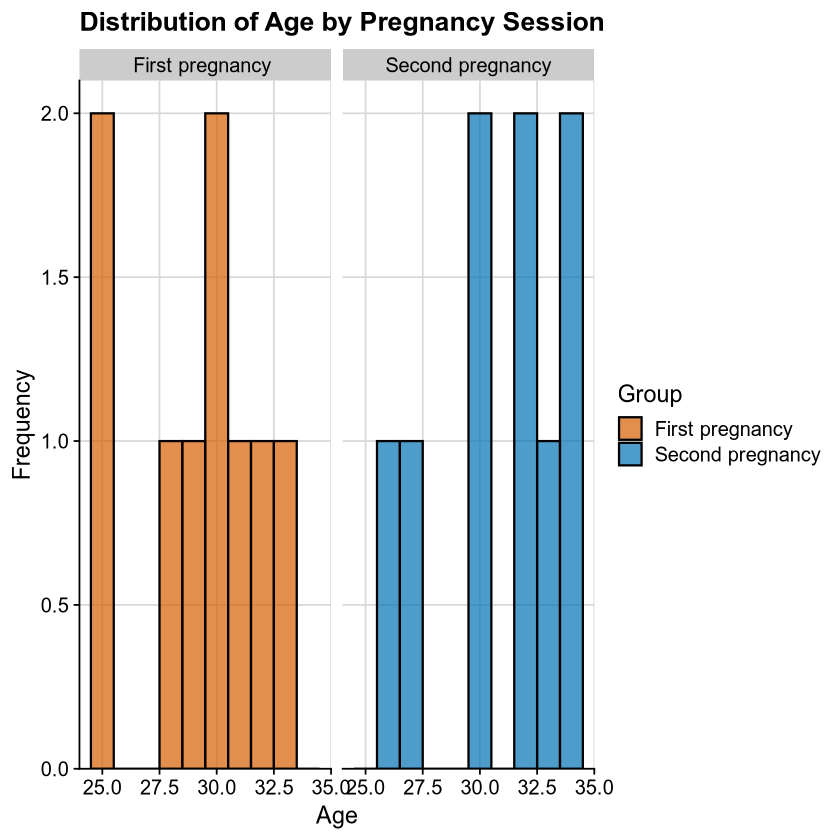

In [216]:
# Histogram of age distribution, grouped by pregnancy session (First vs Second)
age_histogram_combined <- combined_fp_sp |>
  ggplot(aes(x = age_checked, fill = Group)) +
  geom_histogram(bins = 10, col="black", alpha = 0.7, na.rm = TRUE)+
  facet_wrap(~ Group) + # Create one histogram per group 
  labs(
    x = "Age",
    y ="Frequency",
    title ="Distribution of Age by Pregnancy Session"
  ) +
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +    
    scale_fill_manual(values = dye) 
age_histogram_combined + theme_half_open() +
  background_grid()

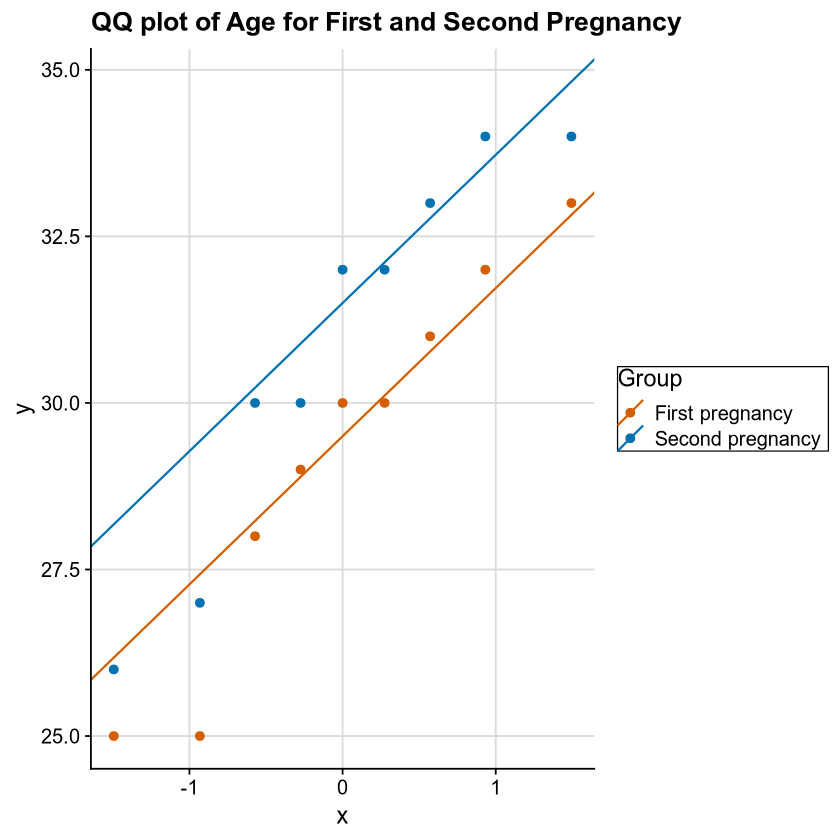

In [217]:
# QQ plot
age_qq_plot <- combined_fp_sp |>
  ggplot(aes(sample = age_checked, color = Group))+
  stat_qq() + 
  stat_qq_line() +
  labs(
    title = "QQ plot of Age for First and Second Pregnancy"
  ) +
  scale_colour_manual(values = dye)  +
  theme_half_open() +
  background_grid() +
  theme(
    legend.box.background = element_rect(color = "black")
  )
age_qq_plot
#display.brewer.all()

In [218]:
# Shapiro test
# In agreement with histogram --> normaly distributed
shapiro_age<- shapiro.test(combined_fp_sp$age_checked)
shapiro_age


	Shapiro-Wilk normality test

data:  combined_fp_sp$age_checked
W = 0.9314, p-value = 0.2055


In [219]:
t_test_age <- t.test(
  combined_fp_sp$age_checked[combined_fp_sp$Group == "First pregnancy "],
  combined_fp_sp$age_checked[combined_fp_sp$Group == "Second pregnancy"],
  paired = TRUE
)
t_test_age


	Paired t-test

data:  combined_fp_sp$age_checked[combined_fp_sp$Group == "First pregnancy "] and combined_fp_sp$age_checked[combined_fp_sp$Group == "Second pregnancy"]
t = -10, df = 8, p-value = 8.488e-06
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -2.051001 -1.282333
sample estimates:
mean difference 
      -1.666667 


### BMI --------------------------------------------------------------------------------------------------------------------------------------------------------------

In [220]:
# BMI (numerical)
combined_fp_sp$BMI_prior

[1] 21 19 24 27 21 24 23 23 23 23 19 33 26 21 27 23 23 21

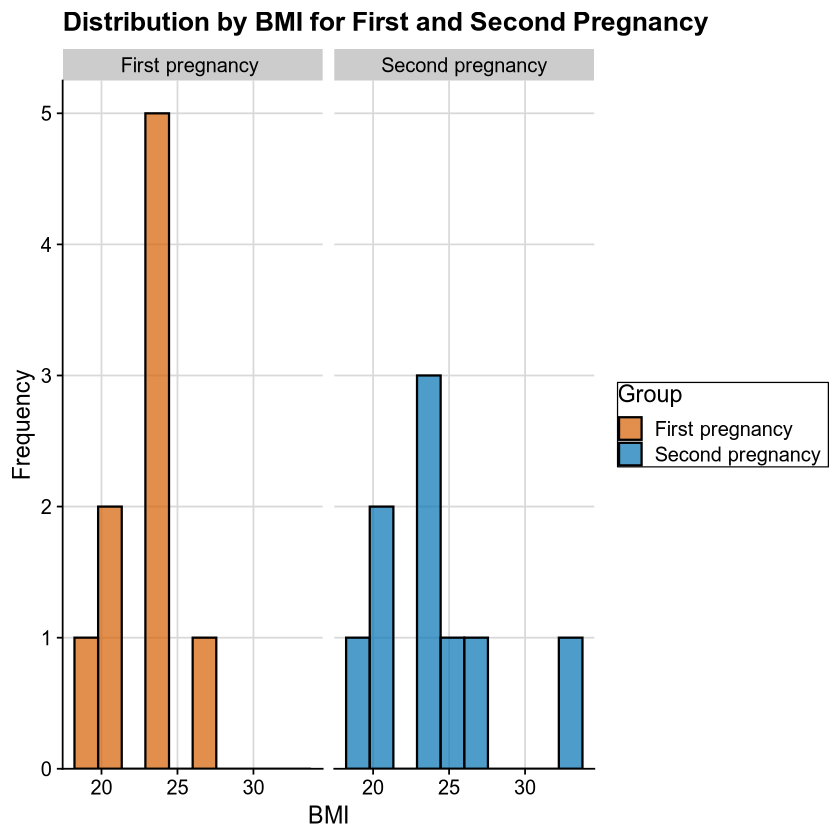

In [221]:
bmi_histogram_combined <- combined_fp_sp |>
  ggplot(aes(x = BMI_prior, fill =Group)) +
  geom_histogram(bins = 10, col = "black", alpha = 0.7, na.rm = TRUE) +
  facet_wrap(~ Group) +
  labs(
    x = "BMI",
    y = "Frequency",
    title = "Distribution by BMI for First and Second Pregnancy"
  ) +
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
    scale_fill_manual(values = dye) +
  theme_half_open() +
  background_grid() +
  theme(
    legend.box.background = element_rect(color = "black")
  )
bmi_histogram_combined

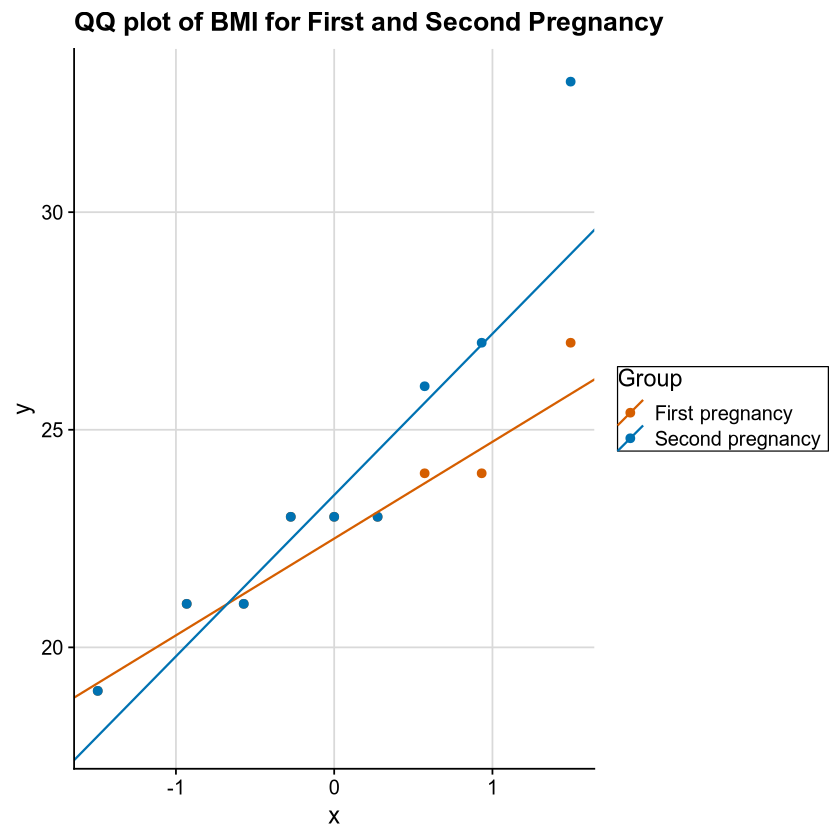

In [222]:
# bmi QQ plot
bmi_qq_plot <- combined_fp_sp |>
  ggplot(aes(sample = BMI_prior, color = Group)) +
  stat_qq() + 
  stat_qq_line() +
  labs (
    title = "QQ plot of BMI for First and Second Pregnancy"
  ) +
  scale_colour_manual(values = dye) +
  theme_half_open() +
  background_grid() +
  theme(
    legend.box.background = element_rect(color = "black")
  )
bmi_qq_plot
  

In [223]:
# Shapiro test
shapiro_bmi <- shapiro.test(combined_fp_sp$BMI_prior)
shapiro_bmi


	Shapiro-Wilk normality test

data:  combined_fp_sp$BMI_prior
W = 0.8732, p-value = 0.0201


In [224]:
# Since non parametric --> wilcoxon
test_age <- wilcox.test( combined_fp_sp$age_checked[combined_fp_sp$Group == "First pregnancy "],
  combined_fp_sp$age_checked[combined_fp_sp$Group == "Second pregnancy"],
  paired = TRUE)
test_age

Warning message in wilcox.test.default(combined_fp_sp$age_checked[combined_fp_sp$Group == :
“cannot compute exact p-value with ties”



	Wilcoxon signed rank test with continuity correction

data:  combined_fp_sp$age_checked[combined_fp_sp$Group == "First pregnancy "] and combined_fp_sp$age_checked[combined_fp_sp$Group == "Second pregnancy"]
V = 0, p-value = 0.006927
alternative hypothesis: true location shift is not equal to 0


In [225]:
t_test_BMI <- t.test(
  combined_fp_sp$BMI_prior[combined_fp_sp$Group == "First pregnancy "],
  combined_fp_sp$BMI_prior[combined_fp_sp$Group == "Second pregnancy"],
  paired = TRUE
)
t_test_BMI


	Paired t-test

data:  combined_fp_sp$BMI_prior[combined_fp_sp$Group == "First pregnancy "] and combined_fp_sp$BMI_prior[combined_fp_sp$Group == "Second pregnancy"]
t = -1.1212, df = 8, p-value = 0.2947
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -3.735948  1.291504
sample estimates:
mean difference 
      -1.222222 


# Categorical ===============================================================================

## Nominal data ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

### Excess weight ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [226]:
class(fp_tp1$excess_weight)
class(sp_tp1$excess_weight)

[1] "character"

[1] "character"

In [227]:
# Convert to factor
fp_tp1 <- fp_tp1 |>
  mutate(excess_weight = as.factor(ifelse(fp_tp1$excess_weight == "NA", NA, ifelse(excess_weight =="No", 0, 1)))) 
sp_tp1 <- sp_tp1 |>
  mutate(excess_weight = as.factor(ifelse(sp_tp1$excess_weight == "NA", NA, ifelse(excess_weight =="No", 0, 1)))) 

In [228]:
# Select variables of interest
fp_excess_weight <- fp_tp1 |>
  select(Q1_Personnummer, excess_weight)
sp_excess_weight <- sp_tp1 |>
  select(Q1_Personnummer, excess_weight)

In [229]:
combined_df_excess_weight <-  merge(fp_excess_weight, sp_excess_weight, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
dim(combined_df_excess_weight)
combined_df_excess_weight

[1] 9 3

Q1_Personnummer,excess_weight_FP,excess_weight_SP
<chr>,<fct>,<fct>
P3db7da6,0,1
P50f102c,0,0
P735d77f,0,1
P7ece52e,0,0
Pbbb08bd,0,1
Pc9a3575,1,0
Pca94a0f,1,1
Pdab1897,0,0
Pe706703,0,NA


In [230]:
combined_df_excess_weight |> filter(is.na(combined_df_excess_weight$excess_weight_FP))
combined_df_excess_weight |> filter(is.na(combined_df_excess_weight$excess_weight_SP))

Q1_Personnummer,excess_weight_FP,excess_weight_SP
<chr>,<fct>,<fct>


Q1_Personnummer,excess_weight_FP,excess_weight_SP
<chr>,<fct>,<fct>
Pe706703,0,NA


In [231]:
# Contingency table
tab_excess_weight <- table(
    factor(combined_df_excess_weight$excess_weight_FP, levels = c(0,1)),
    factor(combined_df_excess_weight$excess_weight_SP, levels = c (0, 1)))
tab_excess_weight

   
    0 1
  0 3 3
  1 1 1

In [232]:
# Non-parametric paired categorical data --> use McNemar's test
mcnemar.test(tab_excess_weight)


	McNemar's Chi-squared test with continuity correction

data:  tab_excess_weight
McNemar's chi-squared = 0.25, df = 1, p-value = 0.6171


In [233]:
# Since  missing values come from differen participants, use Method D

In [234]:
# Select variables of interest
fp_excess_weight <- fp_tp1 |>
  select(Q1_Personnummer, excess_weight)
sp_excess_weight <- sp_tp1 |>
  select(Q1_Personnummer, excess_weight)

In [235]:
# Combine both df so each personal# has two values
combined_df_weight <- merge(fp_excess_weight, sp_excess_weight, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_weight |> head()

,Q1_Personnummer,excess_weight_FP,excess_weight_SP
,<chr>,<fct>,<fct>
1,P3db7da6,0,1
2,P50f102c,0,0
3,P735d77f,0,1
4,P7ece52e,0,0
5,Pbbb08bd,0,1
6,Pc9a3575,1,0


In [236]:
# NA ONLY for fp
missing_pn_weight_fp <- combined_df_weight|> filter(is.na(combined_df_weight$excess_weight_FP) & !is.na(combined_df_weight$excess_weight_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_weight_fp

character(0)

In [237]:
# NA ONLY for sp
missing_pn_weight_sp <- combined_df_weight|> filter(is.na(combined_df_weight$excess_weight_SP) & !is.na(combined_df_weight$excess_weight_FP)) |> 
  pull(Q1_Personnummer)
missing_pn_weight_sp

[1] "Pe706703"

In [238]:
# Pull personal# where NA for BOTH fp AND sp
missing_pn_weight_both  <- combined_df_weight |> 
    filter(is.na(combined_df_weight$excess_weight_FP) & is.na(combined_df_weight$excess_weight_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_weight_both
length(missing_pn_weight_both) # no pn are missing for both

character(0)

[1] 0

In [239]:
# P-value
# Make sure stress_FP and stress_SP are numeric (NOT factors)
combined_df_weight$excess_weight_FP <- as.numeric(as.character(combined_df_weight$excess_weight_FP))
combined_df_weight$excess_weight_SP <- as.numeric(as.character(combined_df_weight$excess_weight_SP))

In [240]:
# 2. Split into groups
m2 <- combined_df_weight[!is.na(combined_df_weight$excess_weight_SP) & !is.na(combined_df_weight$excess_weight_FP), ] # complete
m1 <- combined_df_weight[!is.na(combined_df_weight$excess_weight_FP) & is.na(combined_df_weight$excess_weight_SP), ]  # only FP 
m3 <- combined_df_weight[is.na(combined_df_weight$excess_weight_FP) & !is.na(combined_df_weight$excess_weight_SP), ]  # only SP

In [241]:
m2 |> dim()
m1 |> dim() # NA for sp
m3 |> dim() # NA for fp

[1] 8 3

[1] 1 3

[1] 0 3

In [242]:
# 3. Sizes
n_total <- nrow(combined_df_weight)
m1_n <- nrow(m1)
m2_n <- nrow(m2)
m3_n <- nrow(m3)

Pms <- m1_n / n_total # missing depression SP
Pmt <- m3_n / n_total # missing depression SP
Pms

[1] 0.1111111

In [243]:
# 4. Paired estimator Δ̂(P)
delta_paired <- mean(m2$excess_weight_SP - m2$excess_weight_FP, na.rm = TRUE)
delta_paired

[1] 0.25

In [244]:
# 5. Unpaired estimator Δ̂(U)
P_s <- mean(m1$excess_weight_FP, na.rm = TRUE) # from m1
P_t <- mean(m3$excess_weight_SP, na.rm = TRUE) # from m3
delta_unpaired <- P_t - P_s
delta_unpaired
P_t
P_s

[1] NaN

[1] NaN

[1] 0

In [245]:
# 6. Calculate components for V_P
P01 <- sum(m2$excess_weight_FP == 0 & m2$excess_weight_SP == 1) / m2_n
P10 <- sum(m2$excess_weight_FP == 1 & m2$excess_weight_SP == 0) / m2_n
P01
P10


VP <- (P01 + P10 - (P01 - P10)^2) / (1 - Pms - Pmt)
VP

[1] 0.375

[1] 0.125

[1] 0.4921875

In [246]:
# 7. Calculate VU
VU <- (P_s * (1 - P_s)) / Pms + (P_t * (1 - P_t)) / Pmt
VU

[1] NaN

In [247]:
# 8. Weight w and hybrid estimator
w <- VU / (VU + VP)
delta_D <- w * delta_unpaired + (1 - w) * delta_paired

In [248]:
# 9. Combined variance and SE
var_D <- (VU * VP) / (VU + VP)
se_D <- sqrt(var_D)

In [249]:
# 10. Z-test
z_value <- delta_D / se_D
p_value <- 2 * (1 - pnorm(abs(z_value)))
print(p_value)

[1] NaN


In [250]:
class(fp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes)
class(sp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes)

[1] "logical"

[1] "logical"

In [251]:
combined_fp_sp$Q1_X73.1_Pregnancy_problems_gestational_diabetes

[1] NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA

In [252]:
fp_tp1 <- fp_tp1 |>
  mutate(Q1_X73.1_Pregnancy_problems_gestational_diabetes = as.factor(ifelse(fp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes == "Nej", 0, 1)))
sp_tp1 <- sp_tp1 |>
  mutate(Q1_X73.1_Pregnancy_problems_gestational_diabetes = as.factor(ifelse(sp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes == "Nej", 0, 1)))

In [253]:
fp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes
sp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes

[1] <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA>
Levels:

[1] <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA>
Levels:

In [254]:
fp_diabetes <- fp_tp1 |>
  select(Q1_Personnummer, Q1_X73.1_Pregnancy_problems_gestational_diabetes)
sp_diabetes <- sp_tp1 |>
  select(Q1_Personnummer, Q1_X73.1_Pregnancy_problems_gestational_diabetes)

In [255]:
combined_df_diabetes <- merge(fp_diabetes, sp_diabetes, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_diabetes
dim(combined_df_diabetes)

Q1_Personnummer,Q1_X73.1_Pregnancy_problems_gestational_diabetes_FP,Q1_X73.1_Pregnancy_problems_gestational_diabetes_SP
<chr>,<fct>,<fct>
P3db7da6,NA,NA
P50f102c,NA,NA
P735d77f,NA,NA
P7ece52e,NA,NA
Pbbb08bd,NA,NA
Pc9a3575,NA,NA
Pca94a0f,NA,NA
Pdab1897,NA,NA
Pe706703,NA,NA


[1] 9 3

In [256]:
tab_diabetes <- table(
  factor(combined_df_diabetes$Q1_X73.1_Pregnancy_problems_gestational_diabetes_FP, levels = c(0, 1)),
  factor(combined_df_diabetes$Q1_X73.1_Pregnancy_problems_gestational_diabetes_SP, levels = c(0, 1))
)

In [257]:
tab_diabetes 
mcnemar.test(tab_diabetes)

   
    0 1
  0 0 0
  1 0 0


	McNemar's Chi-squared test

data:  tab_diabetes
McNemar's chi-squared = NaN, df = 1, p-value = NA


### Depression--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [258]:
class(combined_fp_sp$Depression_score_sum_Q1)

[1] "integer"

In [259]:
# Convert to categories
depression_category_fp <- ifelse(fp_tp1$Depression_score_sum_Q1 >= 0 & fp_tp1$Depression_score_sum_Q1 < 13, 0, 
                                 ifelse(fp_tp1$Depression_score_sum_Q1 >= 13 & fp_tp1$Depression_score_sum_Q1 <= 30, 1, NA))
depression_category_fp

depression_category_sp <- ifelse(sp_tp1$Depression_score_sum_Q1 >= 0 & sp_tp1$Depression_score_sum_Q1 < 13,  0, 
                                 ifelse(sp_tp1$Depression_score_sum_Q1 >= 13 & sp_tp1$Depression_score_sum_Q1 <= 30, 1, NA))
depression_category_sp

[1] 0 0 0 1 0 0 1 0 0

[1] 1 0 0 0 0 0 0 0 0

In [260]:
# Add depression category column
fp_tp1$Q1_Depression_category <- as.factor(depression_category_fp)
sp_tp1$Q1_Depression_category <- as.factor(depression_category_sp)
class(fp_tp1$Q1_Depression_category)

[1] "factor"

In [261]:
fp_depression <- fp_tp1 |>
  select(Q1_Personnummer, Q1_Depression_category)
sp_depression <- sp_tp1 |>
  select(Q1_Personnummer, Q1_Depression_category)

In [262]:
combined_df_depression <- merge(fp_depression, sp_depression, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_depression
dim(combined_df_depression)

Q1_Personnummer,Q1_Depression_category_FP,Q1_Depression_category_SP
<chr>,<fct>,<fct>
P3db7da6,0,1
P50f102c,0,0
P735d77f,0,0
P7ece52e,1,0
Pbbb08bd,0,0
Pc9a3575,0,0
Pca94a0f,1,0
Pdab1897,0,0
Pe706703,0,0


[1] 9 3

In [263]:
tab_depression <- table(combined_df_depression$Q1_Depression_category_FP, combined_df_depression$Q1_Depression_category_SP)
tab_depression

   
    0 1
  0 6 1
  1 2 0

In [264]:
mcnemar.test(tab_depression)


	McNemar's Chi-squared test with continuity correction

data:  tab_depression
McNemar's chi-squared = 0, df = 1, p-value = 1


### Stress--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [265]:
class(combined_fp_sp$high_stress_Q1)

[1] "integer"

In [266]:
fp_tp1$high_stress_Q1 <- as.factor(fp_tp1$high_stress_Q1 )
sp_tp1$high_stress_Q1 <- as.factor(sp_tp1$high_stress_Q1 )
class(fp_tp1$high_stress_Q1)
class(sp_tp1$high_stress_Q1)

[1] "factor"

[1] "factor"

In [267]:
fp_stress <- fp_tp1 |>
  select(Q1_Personnummer, high_stress_Q1)
sp_stress <- sp_tp1 |>
  select(Q1_Personnummer, high_stress_Q1)
head(sp_stress)

,Q1_Personnummer,high_stress_Q1
,<chr>,<fct>
1,P3db7da6,1
2,P50f102c,0
3,P735d77f,1
4,P7ece52e,0
5,Pbbb08bd,0
6,Pc9a3575,0


In [268]:
combined_df_stress <- merge(fp_stress, sp_stress, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
head(combined_df_stress)

,Q1_Personnummer,high_stress_Q1_FP,high_stress_Q1_SP
,<chr>,<fct>,<fct>
1,P3db7da6,0,1
2,P50f102c,0,0
3,P735d77f,0,1
4,P7ece52e,1,0
5,Pbbb08bd,1,0
6,Pc9a3575,0,0


In [269]:
tab_stress <- table(combined_df_stress$high_stress_Q1_FP, combined_df_stress$high_stress_Q1_SP)

In [270]:
mcnemar.test(tab_stress)


	McNemar's Chi-squared test

data:  tab_stress
McNemar's chi-squared = 0, df = 1, p-value = 1


### Smoking

All No

### Alcohol--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [271]:
class(combined_fp_sp$Q1_X64_Alcohol_during_pregnancy)

[1] "integer"

In [272]:
fp_tp1$Q1_X64_Alcohol_during_pregnancy <- as.factor(fp_tp1$Q1_X64_Alcohol_during_pregnancy )
sp_tp1$Q1_X64_Alcohol_during_pregnancy <- as.factor(sp_tp1$Q1_X64_Alcohol_during_pregnancy )
class(fp_tp1$Q1_X64_Alcohol_during_pregnancy)
class(sp_tp1$Q1_X64_Alcohol_during_pregnancy)

[1] "factor"

[1] "factor"

In [273]:
fp_alcohol <- fp_tp1 %>%
  select(Q1_Personnummer, Q1_X64_Alcohol_during_pregnancy)
sp_alcohol <- sp_tp1  %>%
  select(Q1_Personnummer, Q1_X64_Alcohol_during_pregnancy)

In [274]:
combined_df_alcohol <- merge(fp_alcohol, sp_alcohol, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [275]:
tab_alcohol <- table(
  factor(combined_df_alcohol$Q1_X64_Alcohol_during_pregnancy_FP, levels = c(0, 1)),
  factor(combined_df_alcohol$Q1_X64_Alcohol_during_pregnancy_SP, levels = c(0, 1))
)

In [276]:
tab_alcohol 

   
    0 1
  0 8 0
  1 1 0

In [277]:
mcnemar.test(tab_alcohol)


	McNemar's Chi-squared test with continuity correction

data:  tab_alcohol
McNemar's chi-squared = 0, df = 1, p-value = 1


### Antibiotics ------------------------------------------------------------------------------------

All no

In [278]:
class(combined_fp_sp$Q1_X43.Antibiotics_last_3_months)
table(combined_fp_sp$Q1_X43.Antibiotics_last_3_months)

[1] "integer"


 0 
18 

In [279]:
fp_tp1$Q1_X43.Antibiotics_last_3_months <- as.factor(fp_tp1$Q1_X43.Antibiotics_last_3_months )
sp_tp1$Q1_X43.Antibiotics_last_3_months <- as.factor(sp_tp1$Q1_X43.Antibiotics_last_3_months )
class(fp_tp1$Q1_X43.Antibiotics_last_3_months)
class(sp_tp1$Q1_X43.Antibiotics_last_3_months)

[1] "factor"

[1] "factor"

In [280]:
fp_anti <- fp_tp1 |> 
  select(Q1_Personnummer, Q1_X43.Antibiotics_last_3_months) 
sp_anti <- sp_tp1 |>
  select(Q1_Personnummer, Q1_X43.Antibiotics_last_3_months) 

In [281]:
combined_df_anti <- merge(fp_anti, sp_anti, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [282]:
head(combined_df_anti)
dim(combined_df_anti)

,Q1_Personnummer,Q1_X43.Antibiotics_last_3_months_FP,Q1_X43.Antibiotics_last_3_months_SP
,<chr>,<fct>,<fct>
1,P3db7da6,0,0
2,P50f102c,0,0
3,P735d77f,0,0
4,P7ece52e,0,0
5,Pbbb08bd,0,0
6,Pc9a3575,0,0


[1] 9 3

In [283]:
# Create contingency table with two levels
tab_anti <- table(
  factor(combined_df_anti$Q1_X43.Antibiotics_last_3_months_FP, levels = c(0, 1)),
      factor(combined_df_anti$Q1_X43.Antibiotics_last_3_months_SP, levels = c(0, 1))
)
tab_anti

   
    0 1
  0 9 0
  1 0 0

In [284]:
# Non-parametric paired categorical data --> use McNemar's test
mcnemar.test(tab_anti)


	McNemar's Chi-squared test

data:  tab_anti
McNemar's chi-squared = NaN, df = 1, p-value = NA


### Diet --------------------------------------------------------------------------------------------------------------------------------------------------------------

In [285]:
# combined$Q1_healthydiet --> yes if health score less than 3
class(combined_fp_sp$Q1_healthydiet)

[1] "integer"

In [286]:
fp_tp1$Q1_healthydiet <- as.factor(fp_tp1$Q1_healthydiet )
sp_tp1$Q1_healthydiet <- as.factor(sp_tp1$Q1_healthydiet )
class(fp_tp1$Q1_healthydiet)
class(sp_tp1$Q1_healthydiet)

[1] "factor"

[1] "factor"

In [287]:
fp_diet <- fp_tp1 |>
  select(Q1_Personnummer, Q1_healthydiet)
sp_diet <- sp_tp1 |>
  select(Q1_Personnummer, Q1_healthydiet)

In [288]:
combined_df_diet <- merge(fp_diet, sp_diet, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [289]:
tab_diet <- table(combined_df_diet$Q1_healthydiet_FP, combined_df_diet$Q1_healthydiet_SP)
tab_diet

   
    0 1
  0 1 0
  1 1 7

In [290]:
mcnemar.test(tab_diet)


	McNemar's Chi-squared test with continuity correction

data:  tab_diet
McNemar's chi-squared = 0, df = 1, p-value = 1


### Daily fiber--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [291]:
class(combined_fp_sp$Q1_dailyfiber)

[1] "integer"

In [292]:
fp_tp1$Q1_dailyfiber <- as.factor(fp_tp1$Q1_dailyfiber)
sp_tp1$Q1_dailyfiber <- as.factor(sp_tp1$Q1_dailyfiber)
class(fp_tp1$Q1_dailyfiber)
class(sp_tp1$Q1_dailyfiber)

[1] "factor"

[1] "factor"

In [293]:
fp_fiber <- fp_tp1 |>
  select(Q1_Personnummer, Q1_dailyfiber)
sp_fiber <- sp_tp1 |>
  select(Q1_Personnummer, Q1_dailyfiber)

In [294]:
combined_df_fiber <- merge(fp_fiber, sp_fiber, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [295]:
tab_fiber <- table(
    factor(combined_df_fiber$Q1_dailyfiber_FP, levels =c(0,1)), 
    factor(combined_df_fiber$Q1_dailyfiber_SP, levels = c(0,1)))
tab_fiber

   
    0 1
  0 0 0
  1 1 8

In [296]:
mcnemar.test(tab_fiber)


	McNemar's Chi-squared test with continuity correction

data:  tab_fiber
McNemar's chi-squared = 0, df = 1, p-value = 1


###  PCOS--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [297]:
class(combined_fp_sp$Q1_X31_Diagnosed_PCOS)

[1] "character"

In [298]:
fp_tp1 <- fp_tp1 |>
  mutate(Q1_X31_Diagnosed_PCOS = as.factor(ifelse(fp_tp1$Q1_X31_Diagnosed_PCOS == "Vet inte", NA, ifelse(fp_tp1$Q1_X31_Diagnosed_PCOS == "Nej", 0, 1))))
sp_tp1 <- sp_tp1 |>
  mutate(Q1_X31_Diagnosed_PCOS = as.factor(ifelse (sp_tp1$Q1_X31_Diagnosed_PCOS == "Vet inte", NA, ifelse(sp_tp1$Q1_X31_Diagnosed_PCOS == "Nej", 0, 1))))
class(fp_tp1$Q1_X31_Diagnosed_PCOS)
class(sp_tp1$Q1_X31_Diagnosed_PCOS)

[1] "factor"

[1] "factor"

In [299]:
fp_pcos <- fp_tp1 |>
  select(Q1_Personnummer, Q1_X31_Diagnosed_PCOS)
sp_pcos <- sp_tp1 |>
  select(Q1_Personnummer, Q1_X31_Diagnosed_PCOS)
 head(fp_pcos)
head(sp_pcos)

,Q1_Personnummer,Q1_X31_Diagnosed_PCOS
,<chr>,<fct>
1,P3db7da6,0
2,P50f102c,1
3,P735d77f,0
4,P7ece52e,0
5,Pbbb08bd,0
6,Pc9a3575,0


,Q1_Personnummer,Q1_X31_Diagnosed_PCOS
,<chr>,<fct>
1,P3db7da6,0
2,P50f102c,1
3,P735d77f,0
4,P7ece52e,0
5,Pbbb08bd,0
6,Pc9a3575,0


In [300]:
combined_df_pcos <- merge(fp_pcos, sp_pcos, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
head(combined_df_pcos)

,Q1_Personnummer,Q1_X31_Diagnosed_PCOS_FP,Q1_X31_Diagnosed_PCOS_SP
,<chr>,<fct>,<fct>
1,P3db7da6,0,0
2,P50f102c,1,1
3,P735d77f,0,0
4,P7ece52e,0,0
5,Pbbb08bd,0,0
6,Pc9a3575,0,0


In [301]:
# To solve problem with error 
tab_pcos <- table(
  factor(combined_df_pcos$Q1_X31_Diagnosed_PCOS_FP, levels = c(0, 1)), 
  factor(combined_df_pcos$Q1_X31_Diagnosed_PCOS_SP, levels = c(0, 1))
  )
tab_pcos

   
    0 1
  0 6 0
  1 0 2

In [320]:
mcnemar.test(tab_pcos)


	McNemar's Chi-squared test

data:  tab_pcos
McNemar's chi-squared = NaN, df = 1, p-value = NA


## Hypertension ----------------------------------------------------------------------------------

All NO

In [307]:
# Convert to factor
fp_tp1 <- fp_tp1 |>
  mutate(Q1_X73.4_Pregnancy_problems_high_bloodpressure = as.factor(ifelse(fp_tp1$Q1_X73.4_Pregnancy_problems_high_bloodpressure == "NA", NA, 
                                                                    ifelse(Q1_X73.4_Pregnancy_problems_high_bloodpressure =="No", 0, 1)))) 
sp_tp1 <- sp_tp1 |>
  mutate(Q1_X73.4_Pregnancy_problems_high_bloodpressure = as.factor(ifelse(sp_tp1$Q1_X73.4_Pregnancy_problems_high_bloodpressure == "NA", NA, 
                                                                    ifelse(Q1_X73.4_Pregnancy_problems_high_bloodpressure =="No", 0, 1)))) 

In [308]:
fp_BP <- fp_tp1 |>
  select(Q1_Personnummer, Q1_X73.4_Pregnancy_problems_high_bloodpressure)
head(fp_BP)

sp_BP <- sp_tp1 |>
  select(Q1_Personnummer, Q1_X73.4_Pregnancy_problems_high_bloodpressure)
head(sp_BP)

,Q1_Personnummer,Q1_X73.4_Pregnancy_problems_high_bloodpressure
,<chr>,<fct>
1,P3db7da6,NA
2,P50f102c,NA
3,P735d77f,NA
4,P7ece52e,NA
5,Pbbb08bd,NA
6,Pc9a3575,NA


,Q1_Personnummer,Q1_X73.4_Pregnancy_problems_high_bloodpressure
,<chr>,<fct>
1,P3db7da6,NA
2,P50f102c,NA
3,P735d77f,NA
4,P7ece52e,NA
5,Pbbb08bd,NA
6,Pc9a3575,NA


In [309]:
combined_df_BP <- merge(fp_BP, sp_BP, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
head(combined_df_BP)

,Q1_Personnummer,Q1_X73.4_Pregnancy_problems_high_bloodpressure_FP,Q1_X73.4_Pregnancy_problems_high_bloodpressure_SP
,<chr>,<fct>,<fct>
1,P3db7da6,NA,NA
2,P50f102c,NA,NA
3,P735d77f,NA,NA
4,P7ece52e,NA,NA
5,Pbbb08bd,NA,NA
6,Pc9a3575,NA,NA


In [310]:
tab_BP <- table(
    factor(combined_df_BP$Q1_X73.4_Pregnancy_problems_high_bloodpressure, levels = c(0, 1)),
    factor(combined_df_BP$Q1_X73.4_Pregnancy_problems_high_bloodpressure, levels = c(0, 1))
    )
tab_BP

   
    0 1
  0 0 0
  1 0 0

## Dentist ------------------------------------------------------------

In [311]:
class(combined_fp_sp$Q1_X50_Dentist_3_months_before_pregnancy)

[1] "integer"

In [313]:
combined_fp_sp$Q1_X50_Dentist_3_months_before_pregnancy

[1] 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0

In [314]:
fp_tp1$Q1_X50_Dentist_3_months_before_pregnancy <- as.factor(fp_tp1$Q1_X50_Dentist_3_months_before_pregnancy)
fp_tp1$Q1_X50_Dentist_3_months_before_pregnancy
fp_tp1$Q1_X50_Dentist_3_months_before_pregnancy |> class()

[1] 0 0 0 1 0 0 0 0 0
Levels: 0 1

[1] "factor"

In [315]:
sp_tp1$Q1_X50_Dentist_3_months_before_pregnancy <- as.factor(sp_tp1$Q1_X50_Dentist_3_months_before_pregnancy)
sp_tp1$Q1_X50_Dentist_3_months_before_pregnancy
sp_tp1$Q1_X50_Dentist_3_months_before_pregnancy |> class()

[1] 0 0 0 0 1 0 1 1 0
Levels: 0 1

[1] "factor"

In [316]:
fp_dentist <- fp_tp1 |>
  select(Q1_Personnummer, Q1_X50_Dentist_3_months_before_pregnancy)
sp_dentist <- sp_tp1 |>
  select(Q1_Personnummer, Q1_X50_Dentist_3_months_before_pregnancy)
 

In [317]:
combined_df_dentist <- merge(fp_dentist, sp_dentist, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_dentist |> head()

,Q1_Personnummer,Q1_X50_Dentist_3_months_before_pregnancy_FP,Q1_X50_Dentist_3_months_before_pregnancy_SP
,<chr>,<fct>,<fct>
1,P3db7da6,0,0
2,P50f102c,0,0
3,P735d77f,0,0
4,P7ece52e,1,0
5,Pbbb08bd,0,1
6,Pc9a3575,0,0


In [318]:
tab_dentist <- table(combined_df_dentist$Q1_X50_Dentist_3_months_before_pregnancy_FP, combined_df_dentist$Q1_X50_Dentist_3_months_before_pregnancy_SP)
tab_dentist

   
    0 1
  0 5 3
  1 1 0

In [319]:
mcnemar.test(tab_dentist)


	McNemar's Chi-squared test with continuity correction

data:  tab_dentist
McNemar's chi-squared = 0.25, df = 1, p-value = 0.6171


#  Catgorical===============================================================================

## Ordinal data~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~¨¨

### BMI ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [106]:
meta_BMI_update_fp <- fp_tp1 %>%
 mutate(
  BMI_group_prior = case_when(
   BMI_prior < 18.5 ~ "Underweight",
   BMI_prior >= 18.5 & BMI_prior <= 24.9 ~ "Normalweight",
   BMI_prior >= 25 & BMI_prior <= 29.9 ~ "Overweight",
   BMI_prior >= 30 ~ "Obese",
   TRUE ~ NA_character_  
 ))

head(meta_BMI_update_fp)
dim(meta_BMI_update_fp)

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group,Q1_Depression_category,smoking_category_Q1,BMI_group_prior
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<chr>,<int>,<chr>,<lgl>,<lgl>,<int>,<chr>,<fct>,<dbl>,<chr>
1,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,2,⋯,NA,41,Spontaneous,NA,NA,0,First pregnancy,0,0,Normalweight
2,S50f102c,NA,0,0,0,2018-08-05,P50f102c,0,32,3,⋯,NA,41,Spontaneous,NA,NA,0,First pregnancy,0,0,Normalweight
3,S735d77f,NA,0,0,0,2018-08-24,P735d77f,0,25,2,⋯,NA,39,Spontaneous,NA,NA,0,First pregnancy,0,0,Normalweight
4,S9026714,NA,0,0,2,2019-01-02,P7ece52e,0,25,2,⋯,NA,41,Induction,NA,NA,0,First pregnancy,1,0,Overweight
5,Se5be4e8,NA,0,0,0,2018-07-03,Pbbb08bd,0,33,3,⋯,NA,40,Spontaneous,NA,NA,0,First pregnancy,0,0,Normalweight
6,Sc9a3575,NA,0,0,0,2018-01-31,Pc9a3575,0,30,3,⋯,IUFD Jag fick havandeskapsförgiftning i v.22 och var tvungen att bli igångsatt. Flickan föddes i v. 24 +0 och överlevde tyvärr inte.,24,Induction,NA,NA,1,First pregnancy,0,0,Normalweight


[1]   9 569

In [107]:
meta_BMI_update_sp <- sp_tp1 %>%
 mutate(
  BMI_group_prior = case_when(
   BMI_prior < 18.5 ~ "Underweight",
   BMI_prior >= 18.5 & BMI_prior <= 24.9 ~ "Normalweight",
   BMI_prior >= 25 & BMI_prior <= 29.9 ~ "Overweight",
   BMI_prior >= 30 ~ "Obese",
   TRUE ~ NA_character_  
 ))

head(meta_BMI_update_sp)
dim(meta_BMI_update_sp)

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group,Q1_Depression_category,smoking_category_Q1,BMI_group_prior
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<lgl>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<fct>,<dbl>,<chr>
1,S3db7da6,NA,0,0,1,2019-09-24,P3db7da6,0,30,3,⋯,NA,39,Spontaneous,NA,NA,0,Second pregnancy,1,0,Normalweight
2,Sa957143,NA,0,0,1,2020-07-11,P50f102c,0,34,3,⋯,NA,40,Spontaneous,NA,NA,0,Second pregnancy,0,0,Normalweight
3,S9deb4a6,NA,0,0,0,2019-11-20,P735d77f,0,26,2,⋯,NA,39,Spontaneous,NA,NA,0,Second pregnancy,0,0,Obese
4,S7ece52e,NA,0,0,2,2020-10-21,P7ece52e,0,27,2,⋯,NA,40,Spontaneous,NA,NA,0,Second pregnancy,0,0,Overweight
5,Sbbb08bd,NA,0,0,1,2019-11-15,Pbbb08bd,0,34,3,⋯,NA,38,Unlaboured c-section,NA,NA,0,Second pregnancy,0,0,Normalweight
6,S99e6192,NA,0,0,1,2020-05-15,Pc9a3575,0,32,3,⋯,NA,28,Spontaneous,very_w28_31,1,1,Second pregnancy,0,0,Overweight


[1]   9 569

In [108]:
# Merge the two dataframes by personal numbers
fp_bmi <- meta_BMI_update_fp |>
  select(Q1_Personnummer, BMI_group_prior)
sp_bmi <- meta_BMI_update_sp |>
  select(Q1_Personnummer, BMI_group_prior)

In [109]:
bmi_merged <- merge(fp_bmi, sp_bmi, by = "Q1_Personnummer", suffixes = c("_fp", "_sp"))
head(bmi_merged)
dim(bmi_merged)

,Q1_Personnummer,BMI_group_prior_fp,BMI_group_prior_sp
,<chr>,<chr>,<chr>
1,P3db7da6,Normalweight,Normalweight
2,P50f102c,Normalweight,Normalweight
3,P735d77f,Normalweight,Obese
4,P7ece52e,Overweight,Overweight
5,Pbbb08bd,Normalweight,Normalweight
6,Pc9a3575,Normalweight,Overweight


[1] 9 3

In [110]:
sum(is.na(bmi_merged))

[1] 0

In [111]:
# Wherever there is a missing value, replace it with NA
bmi_merged[bmi_merged == "Missing"] <- NA
sum(is.na(bmi_merged))

[1] 0

In [112]:
head(bmi_merged)
dim(bmi_merged)

,Q1_Personnummer,BMI_group_prior_fp,BMI_group_prior_sp
,<chr>,<chr>,<chr>
1,P3db7da6,Normalweight,Normalweight
2,P50f102c,Normalweight,Normalweight
3,P735d77f,Normalweight,Obese
4,P7ece52e,Overweight,Overweight
5,Pbbb08bd,Normalweight,Normalweight
6,Pc9a3575,Normalweight,Overweight


[1] 9 3

In [113]:
# Drop the missing values, because it will effect the results
bmi_merged_clean <- bmi_merged |>
  filter(!is.na(BMI_group_prior_fp) & !is.na(BMI_group_prior_sp))

In [114]:
head(bmi_merged_clean)
dim(bmi_merged_clean)
sum(is.na(bmi_merged_clean))

,Q1_Personnummer,BMI_group_prior_fp,BMI_group_prior_sp
,<chr>,<chr>,<chr>
1,P3db7da6,Normalweight,Normalweight
2,P50f102c,Normalweight,Normalweight
3,P735d77f,Normalweight,Obese
4,P7ece52e,Overweight,Overweight
5,Pbbb08bd,Normalweight,Normalweight
6,Pc9a3575,Normalweight,Overweight


[1] 9 3

[1] 0

In [115]:
table(bmi_merged_clean$BMI_group_prior_fp)
table(bmi_merged_clean$BMI_group_prior_sp)


Normalweight   Overweight 
           8            1 


Normalweight        Obese   Overweight 
           6            1            2 

In [116]:
# Define the order of categories
bmi_levels <- c("Underweight", "Normalweight", "Overweight", "Obese")

In [121]:
#fp
bmi_merged_clean$BMI_3_groups_fp <- factor(bmi_merged_clean$BMI_3_groups_fp, levels = bmi_levels, ordered = TRUE)
class(bmi_merged_clean$BMI_3_groups_fp)

[1] "ordered" "factor"

In [118]:
#sp
bmi_merged_clean$BMI_group_prior_sp <- factor(bmi_merged_clean$BMI_group_prior_sp, levels = bmi_levels, ordered = TRUE)
class(bmi_merged_clean$BMI_group_prior_sp)

[1] "ordered" "factor"

In [119]:
# Compute the sign of the change
# Compare ordinal ranks
bmi_merged_clean$sign <- sign(as.numeric(bmi_merged_clean$BMI_group_prior_sp) - as.numeric(bmi_merged_clean$BMI_group_prior_fp))
bmi_merged_clean$sign 

[1] 0 0 1 0 0 1 0 0 0

In [120]:
#sign = 1 BMI category increased
#sign = -1 BMI category decreased
#sign = 0 no change (tie)

table(bmi_merged_clean$sign)
sum(is.na(bmi_merged_clean$sign))


0 1 
7 2 

[1] 0

In [121]:
# Run the sign test 
SIGN.test(
  x = as.numeric(bmi_merged_clean$BMI_group_prior_fp),
  y = as.numeric(bmi_merged_clean$BMI_group_prior_sp),
  alternative = "two.sided",
  paired = TRUE
)


	Dependent-samples Sign-Test

data:  as.numeric(bmi_merged_clean$BMI_group_prior_fp) and as.numeric(bmi_merged_clean$BMI_group_prior_sp)
S = 0, p-value = 0.5
alternative hypothesis: true median difference is not equal to 0
95 percent confidence interval:
 -0.9222222  0.0000000
sample estimates:
median of x-y 
            0 

Achieved and Interpolated Confidence Intervals: 

                  Conf.Level  L.E.pt U.E.pt
Lower Achieved CI     0.8203  0.0000      0
Interpolated CI       0.9500 -0.9222      0
Upper Achieved CI     0.9609 -1.0000      0
